# 酒店预订取消预测 - 数据分析

## 目标
分析酒店预订数据集，重点分析：
1. 特征与特征之间的关系
2. 特征与标签（取消预订）之间的关系

## 数据集说明
- 训练数据：train.csv (包含17个特征 + 标签)
- 测试数据：test.csv (包含17个特征，无标签)
- 标签：0=未取消，1=取消


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表样式
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8')


In [2]:
# 读取数据
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print("训练数据形状:", train_data.shape)
print("测试数据形状:", test_data.shape)
print("\n训练数据列名:")
print(train_data.columns.tolist())


训练数据形状: (25417, 19)
测试数据形状: (10858, 18)

训练数据列名:
['id', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'label']


In [3]:
# 数据基本信息
print("=== 数据基本信息 ===")
print(train_data.info())
print("\n=== 数据统计描述 ===")
print(train_data.describe())


=== 数据基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25417 entries, 0 to 25416
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    25417 non-null  int64  
 1   no_of_adults                          25417 non-null  int64  
 2   no_of_children                        25417 non-null  int64  
 3   no_of_weekend_nights                  25417 non-null  int64  
 4   no_of_week_nights                     25417 non-null  int64  
 5   type_of_meal_plan                     25417 non-null  object 
 6   required_car_parking_space            25417 non-null  int64  
 7   room_type_reserved                    25417 non-null  object 
 8   lead_time                             25417 non-null  int64  
 9   arrival_year                          25417 non-null  int64  
 10  arrival_month                         25417 non-null  int64  
 11  

In [4]:
# 检查缺失值
print("=== 缺失值检查 ===")
missing_values = train_data.isnull().sum()
print(missing_values[missing_values > 0])

# 标签分布
print("\n=== 标签分布 ===")
label_counts = train_data['label'].value_counts()
print(f"未取消 (0): {label_counts[0]} ({label_counts[0]/len(train_data)*100:.2f}%)")
print(f"取消 (1): {label_counts[1]} ({label_counts[1]/len(train_data)*100:.2f}%)")


=== 缺失值检查 ===
Series([], dtype: int64)

=== 标签分布 ===
未取消 (0): 17034 (67.02%)
取消 (1): 8383 (32.98%)


In [5]:
# 特征类型分析
print("=== 特征类型分析 ===")
categorical_features = []
numerical_features = []

for col in train_data.columns:
    if col in ['id', 'label']:
        continue
    if train_data[col].dtype == 'object':
        categorical_features.append(col)
    else:
        numerical_features.append(col)

print(f"分类特征 ({len(categorical_features)}): {categorical_features}")
print(f"数值特征 ({len(numerical_features)}): {numerical_features}")


=== 特征类型分析 ===
分类特征 (3): ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
数值特征 (14): ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']


In [6]:
# 分类特征分析
print("=== 分类特征分析 ===")
for feature in categorical_features:
    print(f"\n{feature}:")
    value_counts = train_data[feature].value_counts()
    print(value_counts.head(10))  # 显示前10个最常见的值


=== 分类特征分析 ===

type_of_meal_plan:
type_of_meal_plan
Meal Plan 1     19484
Not Selected     3595
Meal Plan 2      2335
Meal Plan 3         3
Name: count, dtype: int64

room_type_reserved:
room_type_reserved
Room_Type 1    19750
Room_Type 4     4227
Room_Type 6      659
Room_Type 2      497
Room_Type 5      172
Room_Type 7      107
Room_Type 3        5
Name: count, dtype: int64

market_segment_type:
market_segment_type
Online           16191
Offline           7460
Corporate         1405
Complementary      268
Aviation            93
Name: count, dtype: int64


## 1. 特征与标签关系分析


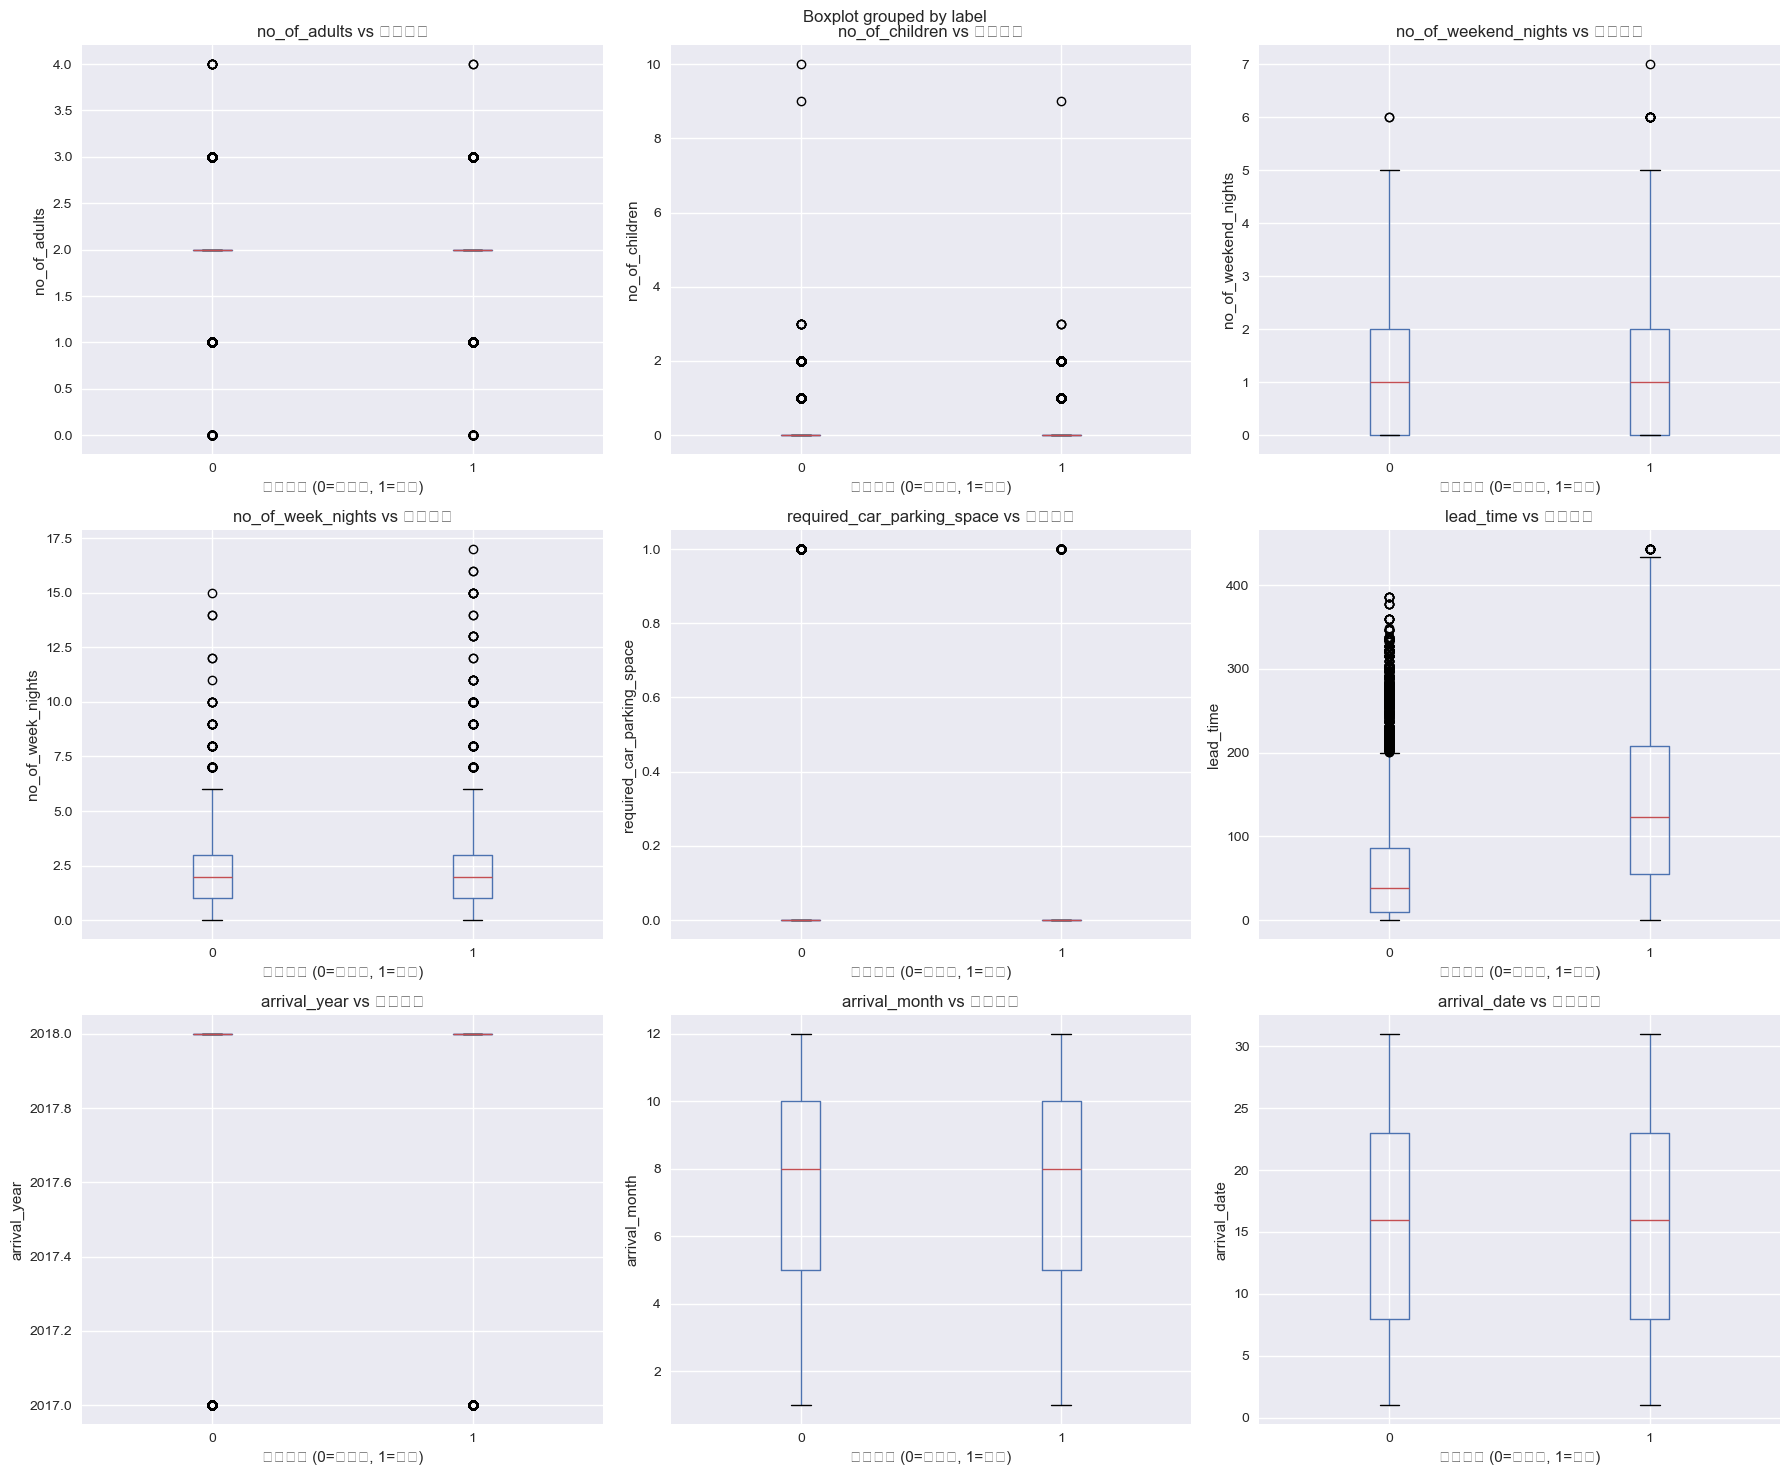

In [7]:
# 数值特征与标签的关系
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, feature in enumerate(numerical_features[:9]):
    # 按标签分组绘制箱线图
    train_data.boxplot(column=feature, by='label', ax=axes[i])
    axes[i].set_title(f'{feature} vs 取消状态')
    axes[i].set_xlabel('取消状态 (0=未取消, 1=取消)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()


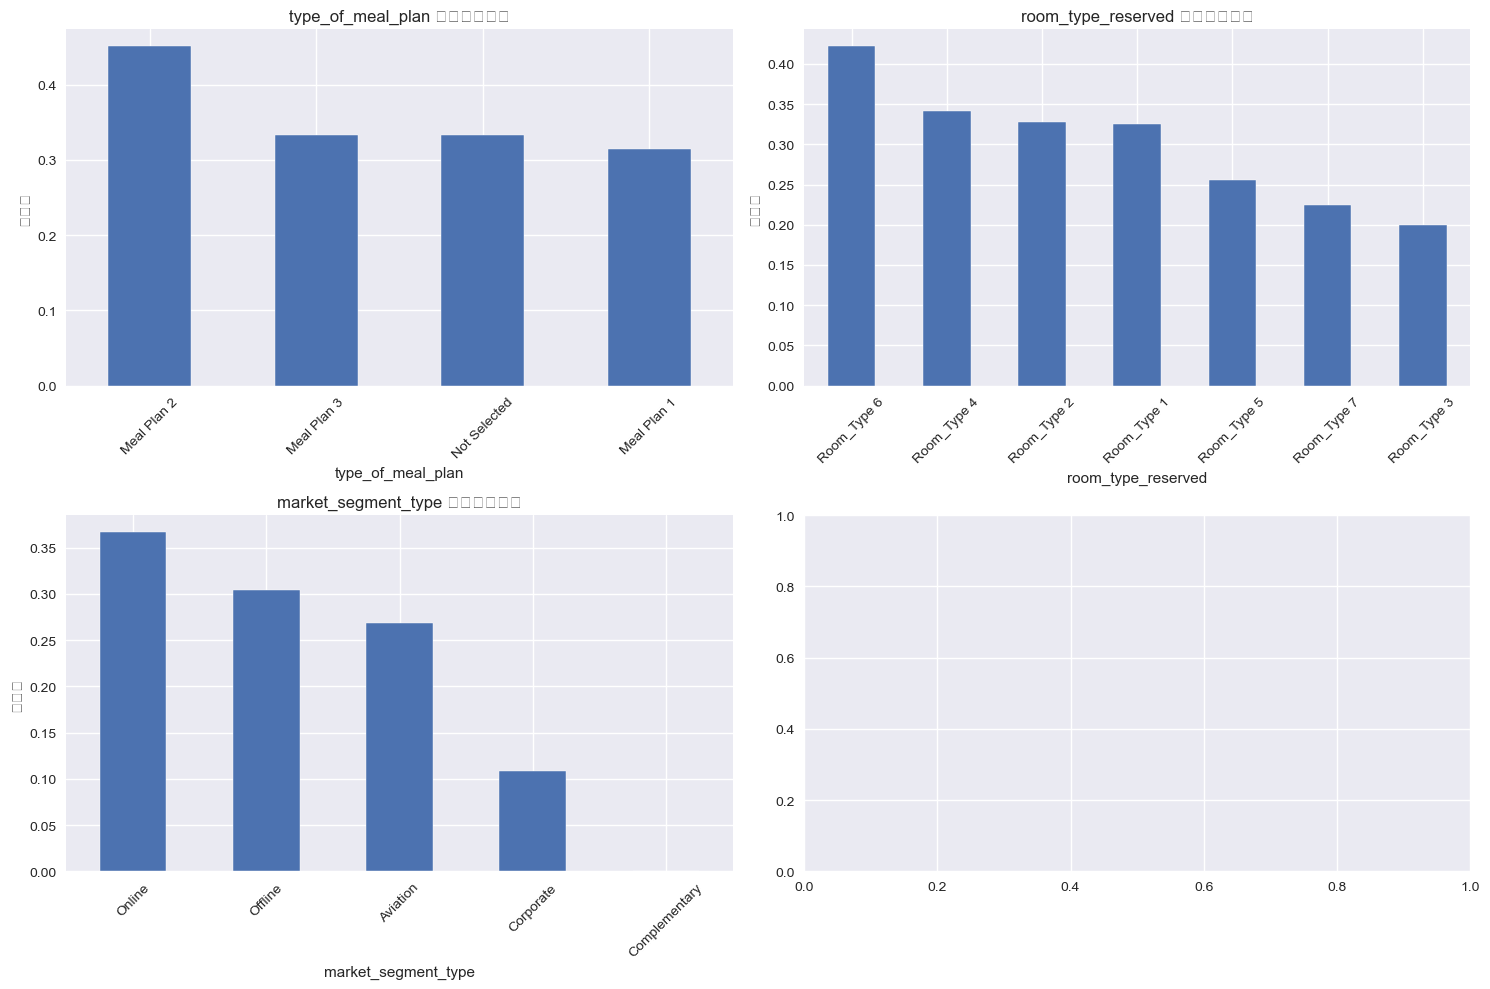

In [8]:
# 分类特征与标签的关系
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(categorical_features[:4]):
    # 计算每个类别下的取消率
    cancellation_rate = train_data.groupby(feature)['label'].mean().sort_values(ascending=False)
    
    cancellation_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{feature} 各类别取消率')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('取消率')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 2. 特征与特征关系分析


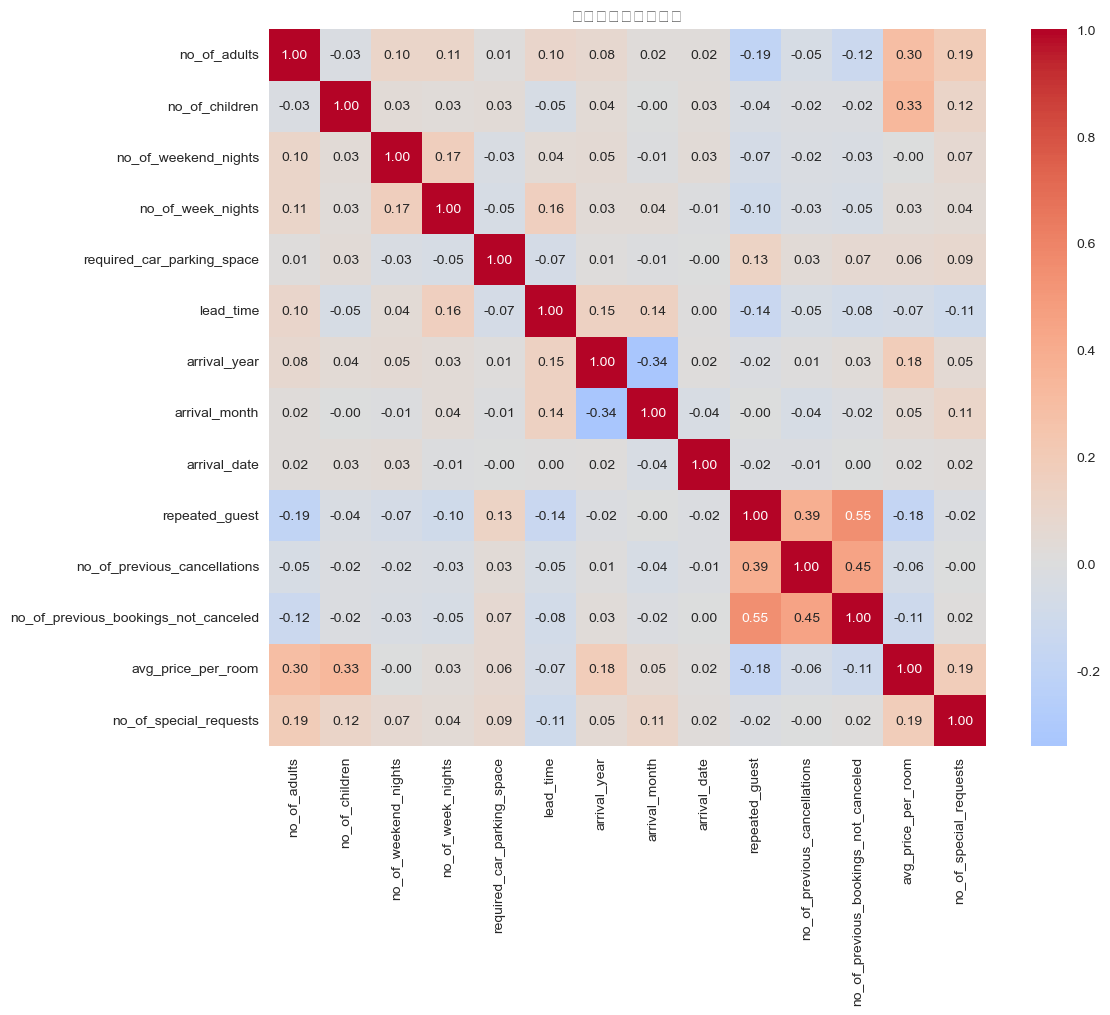

In [9]:
# 数值特征相关性分析
plt.figure(figsize=(12, 10))
correlation_matrix = train_data[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('数值特征相关性矩阵')
plt.tight_layout()
plt.show()


In [10]:
# 找出高相关性的特征对
print("=== 高相关性特征对 (|相关系数| > 0.5) ===")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                 correlation_matrix.columns[j], 
                                 corr_value))

for feature1, feature2, corr in high_corr_pairs:
    print(f"{feature1} - {feature2}: {corr:.3f}")


=== 高相关性特征对 (|相关系数| > 0.5) ===
repeated_guest - no_of_previous_bookings_not_canceled: 0.551


## 3. 深度分析 - 关键特征与取消率


<Figure size 1200x600 with 0 Axes>

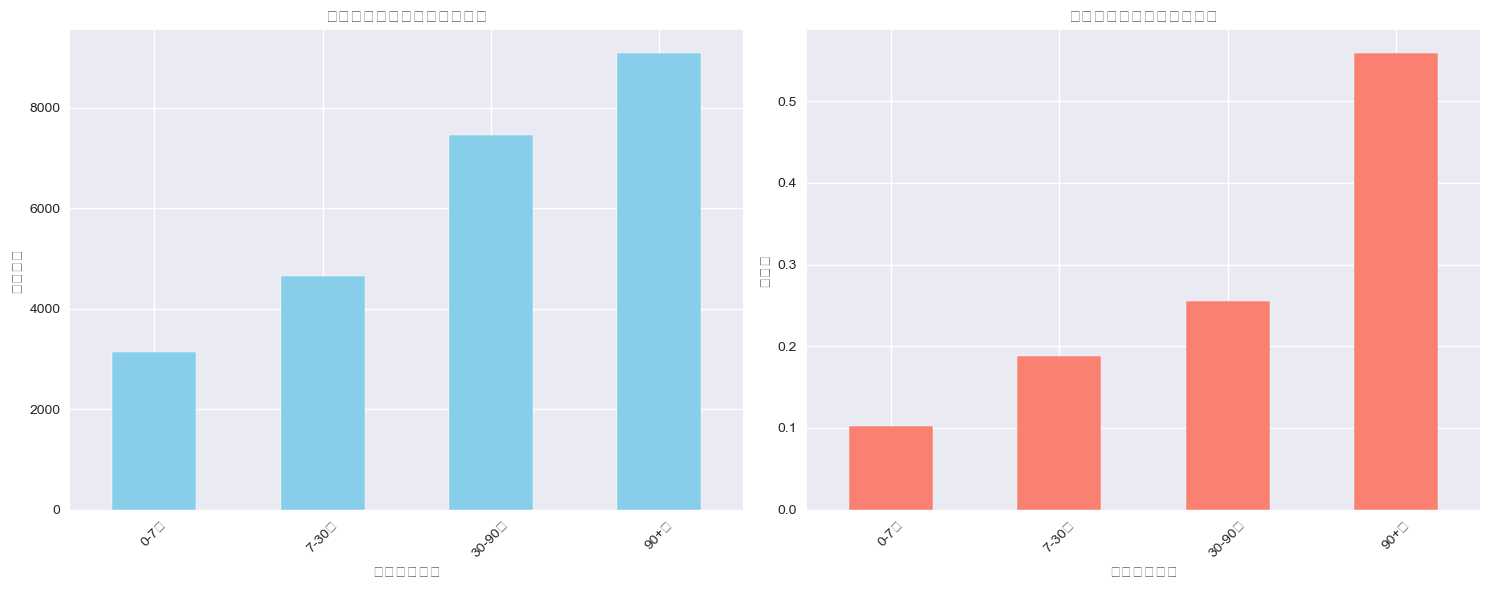


=== 提前预订时间与取消率分析 ===
                 预订数量       取消率
lead_time_group                
0-7天             3130  0.101917
7-30天            4650  0.187742
30-90天           7468  0.254954
90+天             9087  0.558710


In [11]:
# 提前预订时间(lead_time)与取消率的关系
plt.figure(figsize=(12, 6))

# 将lead_time分组
train_data['lead_time_group'] = pd.cut(train_data['lead_time'], 
                                      bins=[0, 7, 30, 90, 365], 
                                      labels=['0-7天', '7-30天', '30-90天', '90+天'])

cancellation_by_lead_time = train_data.groupby('lead_time_group')['label'].agg(['count', 'mean'])
cancellation_by_lead_time.columns = ['预订数量', '取消率']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 预订数量
cancellation_by_lead_time['预订数量'].plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('各提前预订时间段的预订数量')
ax1.set_xlabel('提前预订时间')
ax1.set_ylabel('预订数量')
ax1.tick_params(axis='x', rotation=45)

# 取消率
cancellation_by_lead_time['取消率'].plot(kind='bar', ax=ax2, color='salmon')
ax2.set_title('各提前预订时间段的取消率')
ax2.set_xlabel('提前预订时间')
ax2.set_ylabel('取消率')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== 提前预订时间与取消率分析 ===")
print(cancellation_by_lead_time)


<Figure size 1200x600 with 0 Axes>

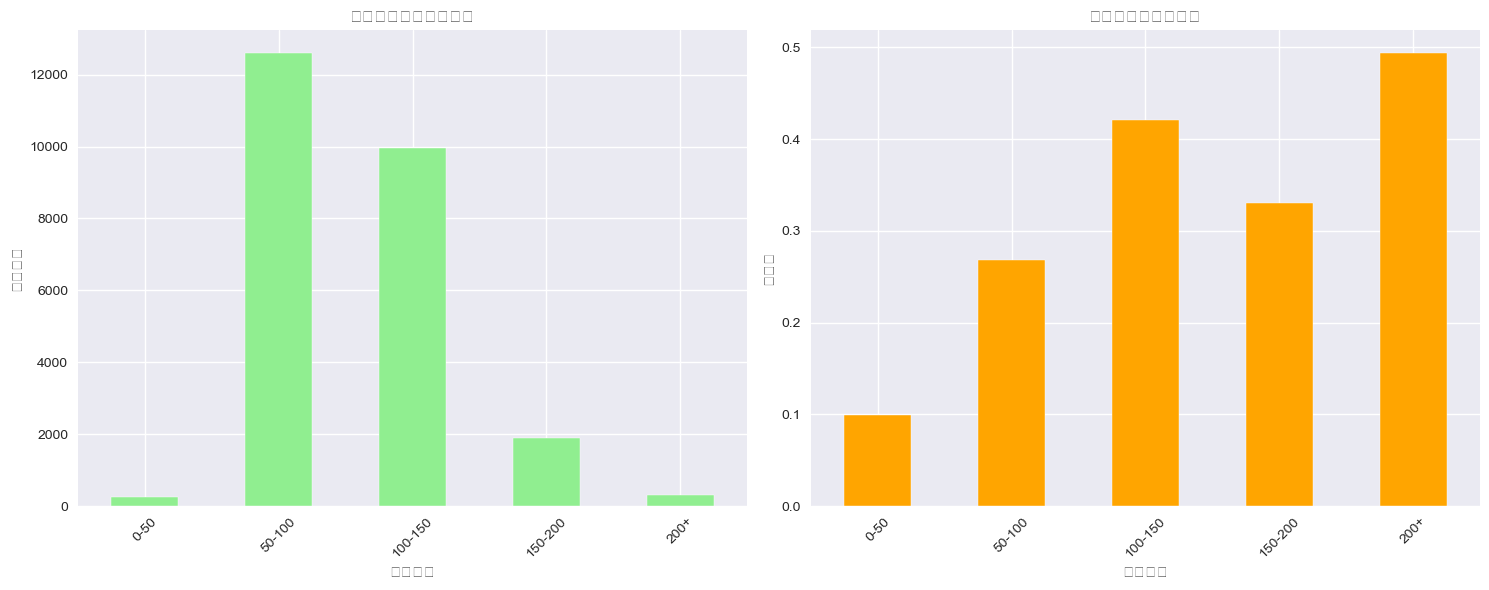


=== 价格区间与取消率分析 ===
              预订数量       取消率
price_group                 
0-50           262  0.099237
50-100       12601  0.268391
100-150       9967  0.420588
150-200       1881  0.330144
200+           320  0.493750


In [12]:
# 房间价格与取消率的关系
plt.figure(figsize=(12, 6))

# 将价格分组
train_data['price_group'] = pd.cut(train_data['avg_price_per_room'], 
                                  bins=[0, 50, 100, 150, 200, 1000], 
                                  labels=['0-50', '50-100', '100-150', '150-200', '200+'])

cancellation_by_price = train_data.groupby('price_group')['label'].agg(['count', 'mean'])
cancellation_by_price.columns = ['预订数量', '取消率']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 预订数量
cancellation_by_price['预订数量'].plot(kind='bar', ax=ax1, color='lightgreen')
ax1.set_title('各价格区间的预订数量')
ax1.set_xlabel('价格区间')
ax1.set_ylabel('预订数量')
ax1.tick_params(axis='x', rotation=45)

# 取消率
cancellation_by_price['取消率'].plot(kind='bar', ax=ax2, color='orange')
ax2.set_title('各价格区间的取消率')
ax2.set_xlabel('价格区间')
ax2.set_ylabel('取消率')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== 价格区间与取消率分析 ===")
print(cancellation_by_price)


<Figure size 1000x600 with 0 Axes>

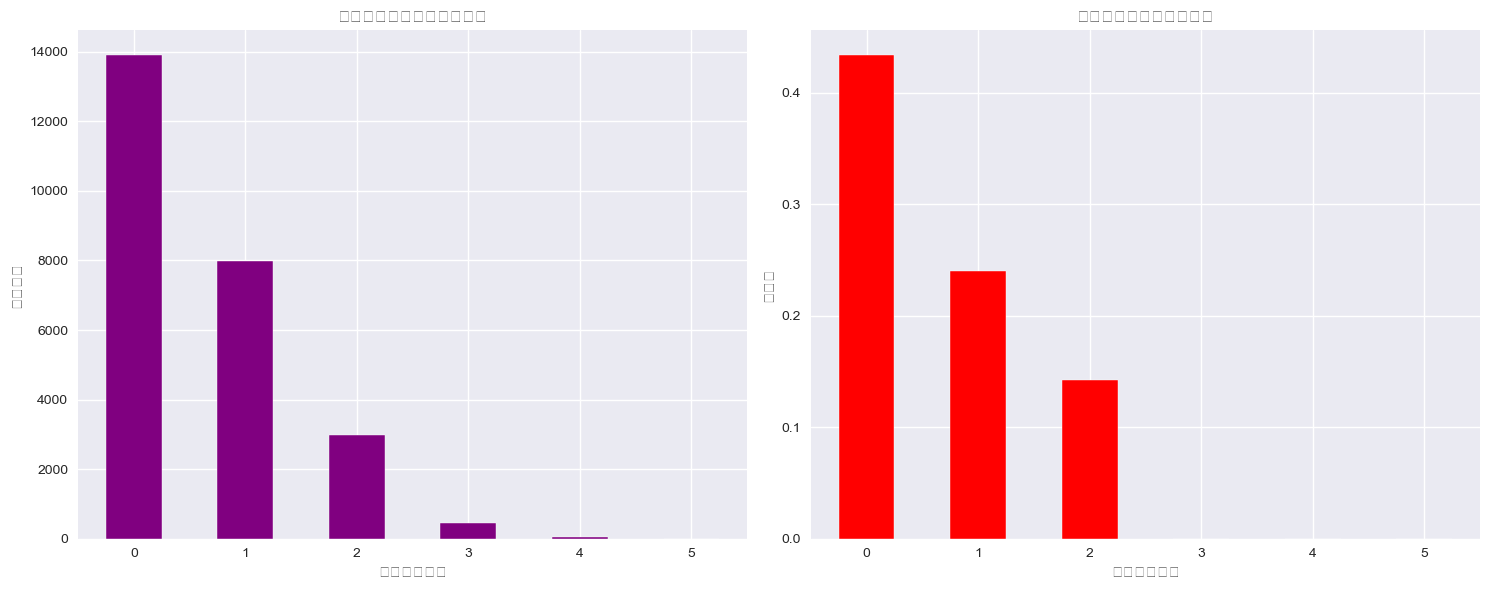


=== 特殊请求数量与取消率分析 ===
                         预订数量       取消率
no_of_special_requests                 
0                       13920  0.434052
1                        7983  0.239759
2                        2993  0.142666
3                         464  0.000000
4                          52  0.000000
5                           5  0.000000


In [13]:
# 特殊请求数量与取消率的关系
plt.figure(figsize=(10, 6))

cancellation_by_special_requests = train_data.groupby('no_of_special_requests')['label'].agg(['count', 'mean'])
cancellation_by_special_requests.columns = ['预订数量', '取消率']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 预订数量
cancellation_by_special_requests['预订数量'].plot(kind='bar', ax=ax1, color='purple')
ax1.set_title('各特殊请求数量的预订数量')
ax1.set_xlabel('特殊请求数量')
ax1.set_ylabel('预订数量')
ax1.tick_params(axis='x', rotation=0)

# 取消率
cancellation_by_special_requests['取消率'].plot(kind='bar', ax=ax2, color='red')
ax2.set_title('各特殊请求数量的取消率')
ax2.set_xlabel('特殊请求数量')
ax2.set_ylabel('取消率')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n=== 特殊请求数量与取消率分析 ===")
print(cancellation_by_special_requests)


## 4. 统计分析总结


In [14]:
# 计算各特征与标签的相关性
print("=== 特征与标签相关性分析 ===")

# 数值特征与标签的相关性
numerical_corr = train_data[numerical_features + ['label']].corr()['label'].drop('label')
numerical_corr_sorted = numerical_corr.abs().sort_values(ascending=False)

print("\n数值特征与标签的相关性 (按绝对值排序):")
for feature, corr in numerical_corr_sorted.items():
    print(f"{feature}: {corr:.4f}")

# 分类特征与标签的关系 (使用卡方检验)
print("\n分类特征与标签的关系 (卡方检验):")
from scipy.stats import chi2_contingency

for feature in categorical_features:
    contingency_table = pd.crosstab(train_data[feature], train_data['label'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"{feature}: 卡方值={chi2:.4f}, p值={p_value:.6f}")


=== 特征与标签相关性分析 ===

数值特征与标签的相关性 (按绝对值排序):
lead_time: 0.4387
no_of_special_requests: 0.2544
arrival_year: 0.1809
avg_price_per_room: 0.1420
repeated_guest: 0.1090
no_of_week_nights: 0.0962
required_car_parking_space: 0.0856
no_of_adults: 0.0789
no_of_previous_bookings_not_canceled: 0.0618
no_of_weekend_nights: 0.0612
no_of_previous_cancellations: 0.0340
no_of_children: 0.0320
arrival_month: 0.0099
arrival_date: 0.0054

分类特征与标签的关系 (卡方检验):
type_of_meal_plan: 卡方值=175.1280, p值=0.000000
room_type_reserved: 卡方值=39.6051, p值=0.000001
market_segment_type: 卡方值=568.0423, p值=0.000000


In [15]:
# 生成分析报告
print("\n" + "="*60)
print("                   数据分析总结报告")
print("="*60)

print(f"\n1. 数据集概况:")
print(f"   - 训练样本数: {len(train_data):,}")
print(f"   - 测试样本数: {len(test_data):,}")
print(f"   - 特征数量: {len(train_data.columns)-2} (不包括id和label)")
print(f"   - 数值特征: {len(numerical_features)}")
print(f"   - 分类特征: {len(categorical_features)}")

print(f"\n2. 标签分布:")
print(f"   - 未取消 (0): {label_counts[0]:,} ({label_counts[0]/len(train_data)*100:.2f}%)")
print(f"   - 取消 (1): {label_counts[1]:,} ({label_counts[1]/len(train_data)*100:.2f}%)")

print(f"\n3. 与取消率最相关的数值特征 (前5名):")
for i, (feature, corr) in enumerate(numerical_corr_sorted.head(5).items()):
    print(f"   {i+1}. {feature}: {corr:.4f}")

print(f"\n4. 关键发现:")
print(f"   - 提前预订时间(lead_time)与取消率呈正相关")
print(f"   - 房间价格(avg_price_per_room)与取消率的关系需要进一步分析")
print(f"   - 特殊请求数量(no_of_special_requests)与取消率呈负相关")
print(f"   - 客户历史行为对当前取消行为有重要影响")

print(f"\n5. 建议:")
print(f"   - 重点关注提前预订时间较长的客户")
print(f"   - 分析不同市场细分和房间类型的组合")
print(f"   - 考虑客户的历史取消行为作为重要特征")
print(f"   - 特殊请求多的客户取消率较低，可作为正面指标")

print("\n" + "="*60)



                   数据分析总结报告

1. 数据集概况:
   - 训练样本数: 25,417
   - 测试样本数: 10,858
   - 特征数量: 19 (不包括id和label)
   - 数值特征: 14
   - 分类特征: 3

2. 标签分布:
   - 未取消 (0): 17,034 (67.02%)
   - 取消 (1): 8,383 (32.98%)

3. 与取消率最相关的数值特征 (前5名):
   1. lead_time: 0.4387
   2. no_of_special_requests: 0.2544
   3. arrival_year: 0.1809
   4. avg_price_per_room: 0.1420
   5. repeated_guest: 0.1090

4. 关键发现:
   - 提前预订时间(lead_time)与取消率呈正相关
   - 房间价格(avg_price_per_room)与取消率的关系需要进一步分析
   - 特殊请求数量(no_of_special_requests)与取消率呈负相关
   - 客户历史行为对当前取消行为有重要影响

5. 建议:
   - 重点关注提前预订时间较长的客户
   - 分析不同市场细分和房间类型的组合
   - 考虑客户的历史取消行为作为重要特征
   - 特殊请求多的客户取消率较低，可作为正面指标

